<a href="https://colab.research.google.com/github/OfEarthAndEther/ML_monologues/blob/main/multi_modal_transfer_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q librosa scikit-learn tqdm
!pip install -q kagglehub gdown
# Verify both frameworks
import torch, tensorflow as tf
print("PyTorch :", torch.__version__, "| GPU:", torch.cuda.is_available())
print("TensorFlow:", tf.__version__)
print("TF GPU:", len(tf.config.list_physical_devices('GPU')) > 0)

PyTorch : 2.10.0+cu128 | GPU: True
TensorFlow: 2.19.0
TF GPU: True


In [2]:
from google.colab import drive
drive.mount('/content/drive')
import os, numpy as np, random

# ── Your existing speech project folder ──────────────────────────
SPEECH_DIR = "/content/drive/MyDrive/speech_emotion_project"

# ── New fusion project folder ─────────────────────────────────────
FUSION_DIR = "/content/drive/MyDrive/multimodal_fusion"
for sub in ["embeddings/speech", "embeddings/fer",
            "embeddings/eeg",  "models", "results"]:
    os.makedirs(f"{FUSION_DIR}/{sub}", exist_ok=True)

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EMBED_DIM = 256   # shared embedding size for all 3 modalities
print("Fusion project ready at:", FUSION_DIR)

Mounted at /content/drive
Fusion project ready at: /content/drive/MyDrive/multimodal_fusion


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import recall_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import torchvision.models as tv_models
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import librosa, cv2, glob, warnings, pickle
from tqdm import tqdm
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

# ── 4-class emotion map used by ALL modalities ────────────────────
# angry=0  happy=1  neutral=2  sad=3
EMO4 = ["angry", "happy", "neutral", "sad"]
print("All imports done. Common 4-class space:", EMO4)

All imports done. Common 4-class space: ['angry', 'happy', 'neutral', 'sad']


In [5]:
class SpeechEmbeddingModel(nn.Module):
    def __init__(self, num_classes=4, embed_dim=256):
        super().__init__()
        resnet = tv_models.resnet18(pretrained=False)
        resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7,
                                  stride=2, padding=3, bias=False)
        children = list(resnet.children())
        self.backbone = nn.Sequential(*children[:-1])

        # ✅ Match ORIGINAL architecture exactly (512 → 128 → 4)
        # so checkpoint weights load without any mismatch
        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(512, 128),   # ← must match saved checkpoint
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

        # ✅ Proj is NEW — not in checkpoint, initialised fresh
        # Added AFTER loading weights, so no conflict
        self.proj = nn.Sequential(
            nn.Linear(512, embed_dim),
            nn.LayerNorm(embed_dim),
            nn.ReLU()
        )

    def embed(self, x):
        """Returns (B, 256). Used by fusion model."""
        x = self.backbone(x).flatten(1)   # (B, 512)
        return self.proj(x)               # (B, 256)

    def forward(self, x):
        x = self.backbone(x).flatten(1)   # (B, 512)
        return self.classifier(x)         # (B, 4)

# Load — now strict=True works because classifier matches exactly
speech_model = SpeechEmbeddingModel(num_classes=4).to(DEVICE)
state = torch.load(f"{SPEECH_DIR}/models/best_model.pt",
                    map_location=DEVICE)
speech_model.load_state_dict(state, strict=False)
speech_model.eval()

# Verify
dummy = torch.randn(2, 1, 64, 300).to(DEVICE)
print("embed() shape:", speech_model.embed(dummy).shape)
# Expected: torch.Size([2, 256])

embed() shape: torch.Size([2, 256])


In [6]:
# ── Re-run feature extraction from your original notebook ─────────
# (copy your extract_mel_fixed and normalisation code here)
# OR load pre-saved features from Drive:

feats_norm  = np.load(f"{SPEECH_DIR}/features/mel_features.npy",
                       allow_pickle=True)
all_labels  = np.load(f"{SPEECH_DIR}/features/labels.npy")
le = LabelEncoder().fit(all_labels)
encoded_labels = le.transform(all_labels)

# Normalize (refit scaler on these features)
from sklearn.preprocessing import StandardScaler
n, h, w = feats_norm.shape
scaler = StandardScaler()
feats_norm = scaler.fit_transform(
    feats_norm.reshape(n,-1)).reshape(n,h,w).astype(np.float32)

# Train/val/test split (same seed as your original notebook)
X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    feats_norm, encoded_labels, test_size=0.30,
    stratify=encoded_labels, random_state=SEED)
X_val, X_te, y_val, y_te = train_test_split(
    X_tmp, y_tmp, test_size=0.50,
    stratify=y_tmp, random_state=SEED)

# Dataset & loaders
class MelDataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X).unsqueeze(1)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

sp_tr_ldr  = DataLoader(MelDataset(X_tr,  y_tr),  batch_size=32)
sp_val_ldr = DataLoader(MelDataset(X_val, y_val), batch_size=32)
sp_te_ldr  = DataLoader(MelDataset(X_te,  y_te),  batch_size=32)

# Extract embeddings
def extract_speech_embs(model, loader):
    model.eval(); embs, labs = [], []
    with torch.no_grad():
        for x, y in loader:
            embs.append(model.embed(x.to(DEVICE)).cpu().numpy())
            labs.extend(y.numpy())
    return np.vstack(embs), np.array(labs)

sp_emb_tr,  sp_y_tr  = extract_speech_embs(speech_model, sp_tr_ldr)
sp_emb_val, sp_y_val = extract_speech_embs(speech_model, sp_val_ldr)
sp_emb_te,  sp_y_te  = extract_speech_embs(speech_model, sp_te_ldr)

print(f"Speech embeddings — Train:{sp_emb_tr.shape} Val:{sp_emb_val.shape} Test:{sp_emb_te.shape}")

# Save
BASE_S = f"{FUSION_DIR}/embeddings/speech"
np.save(f"{BASE_S}/train_emb.npy",    sp_emb_tr)
np.save(f"{BASE_S}/train_labels.npy", sp_y_tr)
np.save(f"{BASE_S}/val_emb.npy",      sp_emb_val)
np.save(f"{BASE_S}/val_labels.npy",   sp_y_val)
np.save(f"{BASE_S}/test_emb.npy",     sp_emb_te)
np.save(f"{BASE_S}/test_labels.npy",  sp_y_te)
print("Speech embeddings saved!")

Speech embeddings — Train:(1008, 256) Val:(216, 256) Test:(216, 256)
Speech embeddings saved!


In [10]:
import kagglehub, cv2

# ── Download FER2013 ──────────────────────────────────────────────
path = kagglehub.dataset_download("deadskull7/fer2013")
import pandas as pd
data = pd.read_csv(f"{path}/fer2013.csv")
data = data.sample(8000, random_state=42)

# ── Preprocess ───────────────────────────────────────────────────
fer_images = []
for pixel in data['pixels']:
    img = np.array(pixel.split(), dtype='float32').reshape(48, 48)
    img = cv2.resize(img, (96, 96))
    img = img / 255.0
    img = np.stack((img,)*3, axis=-1)
    fer_images.append(img)

X_fer = np.array(fer_images)
y_fer = data['emotion'].values

X_fer_tr, X_fer_te, y_fer_tr, y_fer_te = train_test_split(
    X_fer, y_fer, test_size=0.2, random_state=42)

# ── Rebuild MobileNetV2 ───────────────────────────────────────────
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model

base_model = MobileNetV2(weights='imagenet', include_top=False,
                          input_shape=(96, 96, 3))
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(64, activation='relu')(x)
output = layers.Dense(7, activation='softmax')(x)
fer_model = Model(inputs=base_model.input, outputs=output)

# ── FIXED: correct extension .weights.h5 ───────────────────────
FER_WEIGHTS = f"{FUSION_DIR}/models/fer_model.weights.h5"

if os.path.exists(FER_WEIGHTS):
    fer_model.compile(optimizer=tf.keras.optimizers.Adam(0.0001),
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])
    fer_model.load_weights(FER_WEIGHTS)
    print("FER weights loaded from Drive — skipping training")
else:
    fer_model.compile(optimizer=tf.keras.optimizers.Adam(0.0001),
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])
    fer_model.fit(X_fer_tr, y_fer_tr,
                  validation_data=(X_fer_te, y_fer_te),
                  epochs=10, batch_size=16, verbose=1)
    fer_model.save_weights(FER_WEIGHTS)
    print("FER model trained and saved!")

loss, acc = fer_model.evaluate(X_fer_te, y_fer_te, verbose=0)
print(f"FER model accuracy: {acc:.4f}")

Using Colab cache for faster access to the 'fer2013' dataset.
FER weights loaded from Drive — skipping training
FER model accuracy: 0.4487


In [12]:
# ── FER 7-class → 4-class mapping ────────────────────────────────
# FER2013: 0=Angry,1=Disgust,2=Fear,3=Happy,4=Sad,5=Surprise,6=Neutral
FER7_TO_4 = {0:0, 1:2, 2:2, 3:1, 4:3, 5:2, 6:2}
# Result:  angry=0, neutral=2, neutral=2, happy=1, sad=3, neutral=2, neutral=2

# ── Create embedding extractor (at GAP layer = 1280-dim) ──────────
# ── Find GAP layer by type (not name — name changes each rebuild) ─
gap_layer = None
for layer in fer_model.layers:
    if isinstance(layer, tf.keras.layers.GlobalAveragePooling2D):
        gap_layer = layer
        break

if gap_layer is None:
    raise ValueError("Could not find GlobalAveragePooling2D layer")

print("Found GAP layer:", gap_layer.name)  # confirms which one it found

fer_embedder_1280 = Model(inputs=fer_model.input,
                           outputs=gap_layer.output)

# ── Build 1280→256 projector ─────────────────────────────────────
proj_input = tf.keras.Input(shape=(1280,))
proj_out   = layers.Dense(256, activation='relu')(proj_input)
proj_out   = layers.LayerNormalization()(proj_out)
fer_projector = Model(proj_input, proj_out)
fer_projector.compile(optimizer='adam', loss='mse')

FER_PROJ = f"{FUSION_DIR}/models/fer_projector.weights.h5"
if os.path.exists(FER_PROJ):
    fer_projector.load_weights(FER_PROJ)
    print("FER projector loaded from Drive")
else:
    print("FER projector initialised fresh (will be saved after extraction)")

# ── Extract and project all FER embeddings ───────────────────────
FER7_TO_4 = {0:0, 1:2, 2:2, 3:1, 4:3, 5:2, 6:2}

def extract_fer_embs(X, y_7class, batch=256):
    embs_256, labels_4 = [], []
    for i in range(0, len(X), batch):
        xb  = X[i:i+batch]
        gap = fer_embedder_1280.predict(xb, verbose=0)
        prj = fer_projector.predict(gap, verbose=0)
        embs_256.append(prj)
        labels_4.extend([FER7_TO_4[int(l)] for l in y_7class[i:i+batch]])
    return np.vstack(embs_256).astype(np.float32), np.array(labels_4)

fer_emb_tr,  fer_y_tr  = extract_fer_embs(X_fer_tr, y_fer_tr)
fer_emb_te,  fer_y_te  = extract_fer_embs(X_fer_te, y_fer_te)

fer_emb_tr, fer_emb_val, fer_y_tr, fer_y_val = train_test_split(
    fer_emb_tr, fer_y_tr, test_size=0.15,
    stratify=fer_y_tr, random_state=SEED)

print(f"FER embeddings — Train:{fer_emb_tr.shape} Val:{fer_emb_val.shape} Test:{fer_emb_te.shape}")
print("FER 4-class distribution:", dict(zip(*np.unique(fer_y_tr, return_counts=True))))

BASE_F = f"{FUSION_DIR}/embeddings/fer"
np.save(f"{BASE_F}/train_emb.npy",    fer_emb_tr)
np.save(f"{BASE_F}/train_labels.npy", fer_y_tr)
np.save(f"{BASE_F}/val_emb.npy",      fer_emb_val)
np.save(f"{BASE_F}/val_labels.npy",   fer_y_val)
np.save(f"{BASE_F}/test_emb.npy",     fer_emb_te)

Found GAP layer: global_average_pooling2d_2
FER projector initialised fresh (will be saved after extraction)
FER embeddings — Train:(5440, 256) Val:(960, 256) Test:(1600, 256)
FER 4-class distribution: {np.int64(0): np.int64(755), np.int64(1): np.int64(1363), np.int64(2): np.int64(2413), np.int64(3): np.int64(909)}


In [13]:
import gdown
from scipy.signal import butter, filtfilt

# ── DEAP data path: change this to your Drive link or local path ──
DEAP_DRIVE_LINK = ""  # e.g. "https://drive.google.com/..."
DEAP_LOCAL_PATH = "/content/drive/MyDrive/deap"

if os.path.isdir(DEAP_LOCAL_PATH):
    DEAP_PATH = DEAP_LOCAL_PATH
    print("DEAP found locally at:", DEAP_PATH)
elif DEAP_DRIVE_LINK:
    # Use gdown to download
    !pip install -q gdown
    import gdown
    os.makedirs("/content/deap_data", exist_ok=True)
    gdown.download_folder(DEAP_DRIVE_LINK,
                          output="/content/deap_data",
                          quiet=False)
    DEAP_PATH = "/content/deap_data"
else:
    print("WARNING: No DEAP path set. Set DEAP_DRIVE_LINK or DEAP_LOCAL_PATH above.")
    DEAP_PATH = None

# ── Feature extraction functions (from EEG_Emotion_Final.py) ─────
FS = 128
BANDS = {'delta':(1,4),'theta':(4,8),'alpha':(8,14),
         'beta':(14,31),'gamma':(31,50)}

def bandpass(data, low, high, fs=FS, order=5):
    b, a = butter(order, [low/(fs/2), high/(fs/2)], btype='band')
    return filtfilt(b, a, data, axis=-1)

def compute_de(seg):
    v = np.var(seg)
    return 0.5 * np.log(2 * np.pi * np.e * max(v, 1e-10))

def extract_de(eeg):
    n_ch, n_samp = eeg.shape
    n_seg = n_samp // FS
    filtered = {b: bandpass(eeg, lo, hi)
                for b, (lo, hi) in BANDS.items()}
    feats = np.zeros((n_seg, n_ch, len(BANDS)))
    for s in range(n_seg):
        for bi, bn in enumerate(BANDS):
            for ch in range(n_ch):
                feats[s,ch,bi] = compute_de(
                    filtered[bn][ch, s*FS:(s+1)*FS])
    return feats

# ── Load all DEAP subjects ────────────────────────────────────────
def load_deap(data_dir):
    subjects = {}
    for fname in sorted(os.listdir(data_dir)):
        if not fname.endswith('.dat'): continue
        sid = fname.replace('.dat','')
        with open(os.path.join(data_dir,fname),'rb') as f:
            data = pickle.load(f, encoding='latin1')
        eeg = data['data'][:,:32, 3*FS:]
        labels = (data['labels'][:,0] > 5).astype(int)
        feats_l, labels_l = [], []
        for t in range(40):
            de = extract_de(eeg[t])
            feats_l.append(de)
            labels_l.append(np.full(de.shape[0], labels[t]))
        subjects[sid] = {
            'X': np.concatenate(feats_l),
            'y': np.concatenate(labels_l)
        }
    print(f"Loaded {len(subjects)} subjects")
    return subjects

if DEAP_PATH:
    deap_subjects = load_deap(DEAP_PATH)
    print("Sample subject shape:",
          list(deap_subjects.values())[0]['X'].shape)
    # Expected: (N_segments, 32_channels, 5_bands)

In [14]:
# ── EEGNet (identical architecture to EEG_Emotion_Final.py) ──────
def build_eegnet_with_embedding(n_ch=32, n_tp=5, embed_dim=256):
    tf.keras.backend.clear_session()
    inp = layers.Input((n_ch, n_tp, 1), name="eeg_input")
    x = layers.Conv2D(8, (1,n_tp), padding='same', use_bias=False)(inp)
    x = layers.BatchNormalization()(x)
    x = layers.DepthwiseConv2D((n_ch,1), depth_multiplier=2,
                                use_bias=False, padding='valid')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('elu')(x)
    x = layers.AveragePooling2D((1,2), padding='same')(x)
    x = layers.Dropout(0.25)(x)
    x = layers.SeparableConv2D(16,(1,3), padding='same',
                                use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('elu')(x)
    x = layers.AveragePooling2D((1,2), padding='same')(x)
    x = layers.Dropout(0.25)(x)
    x = layers.Flatten()(x)

    # Embedding layer (64-dim, same as original)
    emb_64 = layers.Dense(64, activation='elu', name="eeg_emb")(x)
    x = layers.Dropout(0.3)(emb_64)
    out = layers.Dense(1, activation='sigmoid', name="valence")(x)

    full_model   = models.Model(inp, out)
    embed_model  = models.Model(inp, emb_64)  # extractor
    full_model.compile(optimizer='adam',
                       loss='binary_crossentropy', metrics=['accuracy'])
    return full_model, embed_model

# ── Pool all subjects together ────────────────────────────────────
if DEAP_PATH:
    all_X_eeg = np.concatenate(
        [deap_subjects[s]['X'] for s in sorted(deap_subjects)])[..., np.newaxis]
    all_y_eeg = np.concatenate(
        [deap_subjects[s]['y'] for s in sorted(deap_subjects)])

    # Normalise
    mu = all_X_eeg.mean(0, keepdims=True)
    sg = all_X_eeg.std(0,  keepdims=True) + 1e-8
    all_X_eeg = (all_X_eeg - mu) / sg

    X_eeg_tr, X_eeg_te, y_eeg_tr, y_eeg_te = train_test_split(
        all_X_eeg, all_y_eeg, test_size=0.2,
        stratify=all_y_eeg, random_state=SEED)

    eeg_model, eeg_embedder = build_eegnet_with_embedding()

    EEG_WEIGHTS = f"{FUSION_DIR}/models/eeg_model.weights.h5"
    es = callbacks.EarlyStopping(monitor='val_loss', patience=5,
                                  restore_best_weights=True, verbose=0)
    if os.path.exists(EEG_WEIGHTS):
        eeg_model.load_weights(EEG_WEIGHTS)
        # Sync embedder weights
        eeg_embedder = models.Model(
            inputs=eeg_model.input,
            outputs=eeg_model.get_layer("eeg_emb").output)
        print("EEG weights loaded from Drive")
    else:
        eeg_model.fit(X_eeg_tr, y_eeg_tr, epochs=20, batch_size=64,
                      validation_split=0.1, callbacks=[es], verbose=1)
        eeg_model.save_weights(EEG_WEIGHTS)
        print("EEG model trained and saved!")

    loss, acc = eeg_model.evaluate(X_eeg_te, y_eeg_te, verbose=0)
    print(f"EEG binary valence accuracy: {acc:.4f}")

In [15]:
if DEAP_PATH:
    # ── Build 64→256 projector for EEG ────────────────────────────
    eeg_proj_inp = tf.keras.Input(shape=(64,))
    eeg_proj_out = layers.Dense(256, activation='relu')(eeg_proj_inp)
    eeg_proj_out = layers.LayerNormalization()(eeg_proj_out)
    eeg_projector = models.Model(eeg_proj_inp, eeg_proj_out)

    EEG_PROJ = f"{FUSION_DIR}/models/eeg_projector.h5"
    if os.path.exists(EEG_PROJ):
        eeg_projector.load_weights(EEG_PROJ)

    def extract_eeg_embs(X, y_binary, batch=512):
        """
        y_binary: 0=low valence → proxy 4-class: angry(0) or sad(3)
                  1=high valence → proxy 4-class: happy(1) or neutral(2)
        We randomly assign within each valence group so the fusion
        model sees diverse emotion signals from EEG.
        """
        rng = np.random.default_rng(SEED)
        embs_256, labels_4 = [], []
        for i in range(0, len(X), batch):
            xb = X[i:i+batch]
            yb = y_binary[i:i+batch]
            emb_64 = eeg_embedder.predict(xb, verbose=0)   # (B,64)
            prj    = eeg_projector.predict(emb_64, verbose=0) # (B,256)
            embs_256.append(prj)
            for lv in yb:
                if lv == 0:  # low valence → angry or sad
                    labels_4.append(rng.choice([0, 3]))
                else:        # high valence → happy or neutral
                    labels_4.append(rng.choice([1, 2]))
        return np.vstack(embs_256).astype(np.float32), np.array(labels_4)

    eeg_emb_tr,  eeg_y_tr  = extract_eeg_embs(X_eeg_tr, y_eeg_tr)
    eeg_emb_te,  eeg_y_te  = extract_eeg_embs(X_eeg_te, y_eeg_te)
    eeg_emb_tr, eeg_emb_val, eeg_y_tr, eeg_y_val = train_test_split(
        eeg_emb_tr, eeg_y_tr, test_size=0.15,
        stratify=eeg_y_tr, random_state=SEED)

    print(f"EEG embeddings — Train:{eeg_emb_tr.shape} "
          f"Val:{eeg_emb_val.shape} Test:{eeg_emb_te.shape}")

    BASE_E = f"{FUSION_DIR}/embeddings/eeg"
    np.save(f"{BASE_E}/train_emb.npy",    eeg_emb_tr)
    np.save(f"{BASE_E}/train_labels.npy", eeg_y_tr)
    np.save(f"{BASE_E}/val_emb.npy",      eeg_emb_val)
    np.save(f"{BASE_E}/val_labels.npy",   eeg_y_val)
    np.save(f"{BASE_E}/test_emb.npy",     eeg_emb_te)
    np.save(f"{BASE_E}/test_labels.npy",  eeg_y_te)
    print("EEG embeddings saved!")

In [17]:
# ── Re-extract and save ALL FER embeddings ────────────────────────
FER7_TO_4 = {0:0, 1:2, 2:2, 3:1, 4:3, 5:2, 6:2}

def extract_fer_embs(X, y_7class, batch=256):
    embs_256, labels_4 = [], []
    for i in range(0, len(X), batch):
        xb  = X[i:i+batch]
        gap = fer_embedder_1280.predict(xb, verbose=0)
        prj = fer_projector.predict(gap, verbose=0)
        embs_256.append(prj)
        labels_4.extend([FER7_TO_4[int(l)] for l in y_7class[i:i+batch]])
    return np.vstack(embs_256).astype(np.float32), np.array(labels_4)

print("Extracting train embeddings...")
fer_emb_tr_full, fer_y_tr_full = extract_fer_embs(X_fer_tr, y_fer_tr)

print("Extracting test embeddings...")
fer_emb_te, fer_y_te = extract_fer_embs(X_fer_te, y_fer_te)

# Val split from train
fer_emb_tr, fer_emb_val, fer_y_tr, fer_y_val = train_test_split(
    fer_emb_tr_full, fer_y_tr_full,
    test_size=0.15, stratify=fer_y_tr_full, random_state=SEED)

print(f"Train:{fer_emb_tr.shape} Val:{fer_emb_val.shape} Test:{fer_emb_te.shape}")

# ── Save all 6 files ─────────────────────────────────────────────
BASE_F = f"{FUSION_DIR}/embeddings/fer"
os.makedirs(BASE_F, exist_ok=True)

np.save(f"{BASE_F}/train_emb.npy",    fer_emb_tr)
np.save(f"{BASE_F}/train_labels.npy", fer_y_tr)
np.save(f"{BASE_F}/val_emb.npy",      fer_emb_val)
np.save(f"{BASE_F}/val_labels.npy",   fer_y_val)
np.save(f"{BASE_F}/test_emb.npy",     fer_emb_te)
np.save(f"{BASE_F}/test_labels.npy",  fer_y_te)

# ── Verify all 6 files exist ─────────────────────────────────────
for f in ["train_emb","train_labels","val_emb",
          "val_labels","test_emb","test_labels"]:
    path = f"{BASE_F}/{f}.npy"
    exists = os.path.exists(path)
    print(f"  {'OK' if exists else 'MISSING'} — {f}.npy")

print("\nAll FER embeddings saved!")

Extracting train embeddings...
Extracting test embeddings...
Train:(5440, 256) Val:(960, 256) Test:(1600, 256)
  OK — train_emb.npy
  OK — train_labels.npy
  OK — val_emb.npy
  OK — val_labels.npy
  OK — test_emb.npy
  OK — test_labels.npy

All FER embeddings saved!


In [18]:
def load_embs(base, split):
    return (np.load(f"{base}/{split}_emb.npy"),
            np.load(f"{base}/{split}_labels.npy"))

# ── Speech (always available) ─────────────────────────────────────
sp_tr,  sp_y_tr  = load_embs(f"{FUSION_DIR}/embeddings/speech", "train")
sp_val, sp_y_val = load_embs(f"{FUSION_DIR}/embeddings/speech", "val")
sp_te,  sp_y_te  = load_embs(f"{FUSION_DIR}/embeddings/speech", "test")

# ── FER ───────────────────────────────────────────────────────────
fer_tr,  fer_y_tr  = load_embs(f"{FUSION_DIR}/embeddings/fer", "train")
fer_val, fer_y_val = load_embs(f"{FUSION_DIR}/embeddings/fer", "val")
fer_te,  fer_y_te  = load_embs(f"{FUSION_DIR}/embeddings/fer", "test")

# ── EEG (placeholder if not available) ───────────────────────────
EEG_BASE = f"{FUSION_DIR}/embeddings/eeg"
if os.path.exists(f"{EEG_BASE}/train_emb.npy"):
    eeg_tr,  eeg_y_tr  = load_embs(EEG_BASE, "train")
    eeg_val, eeg_y_val = load_embs(EEG_BASE, "val")
    eeg_te,  eeg_y_te  = load_embs(EEG_BASE, "test")
    EEG_AVAILABLE = True
    print("EEG embeddings loaded from Drive")
else:
    EEG_AVAILABLE = False
    print("EEG not available — using noise placeholder")

print(f"Speech: train={sp_tr.shape} val={sp_val.shape} test={sp_te.shape}")
print(f"FER:    train={fer_tr.shape} val={fer_val.shape} test={fer_te.shape}")

EEG not available — using noise placeholder
Speech: train=(1008, 256) val=(216, 256) test=(216, 256)
FER:    train=(5440, 256) val=(960, 256) test=(1600, 256)


In [19]:
def build_fusion_dataset(sp_emb, sp_y,
                          fer_emb, fer_y,
                          eeg_emb, eeg_y,
                          n_per_class=200,
                          eeg_available=True, seed=42):
    """
    For each of 4 emotion classes, randomly pairs one embedding
    from each modality to form synthetic multi-modal samples.
    Returns X: (N, 768) and y: (N,)
    """
    rng = np.random.default_rng(seed)
    X_list, y_list = [], []

    for cls in range(4):
        # Indices for this class in each modality
        sp_idx  = np.where(sp_y  == cls)[0]
        fer_idx = np.where(fer_y == cls)[0]

        if len(sp_idx) == 0 or len(fer_idx) == 0:
            print(f"  Class {cls} ({EMO4[cls]}): "
                  "skipped — no samples in one modality")
            continue

        n = min(n_per_class, len(sp_idx), len(fer_idx))

        sp_sample  = sp_emb [rng.choice(sp_idx,  n, replace=True)]
        fer_sample = fer_emb[rng.choice(fer_idx, n, replace=True)]

        if eeg_available:
            eeg_idx = np.where(eeg_y == cls)[0]
            if len(eeg_idx) == 0:
                # EEG has no samples for this class → use neutral noise
                eeg_sample = np.zeros((n, 256), dtype=np.float32)
            else:
                eeg_sample = eeg_emb[rng.choice(eeg_idx, n, replace=True)]
        else:
            # Placeholder: unit Gaussian noise (informs model EEG is absent)
            eeg_sample = rng.standard_normal((n, 256)).astype(np.float32)

        fused = np.concatenate([sp_sample, fer_sample, eeg_sample], axis=1)
        X_list.append(fused)
        y_list.extend([cls] * n)
        print(f"  Class {cls} ({EMO4[cls]:<8}): {n} synthetic samples")

    return np.vstack(X_list).astype(np.float32), np.array(y_list)

print("Building TRAIN fusion dataset...")
X_fus_tr, y_fus_tr = build_fusion_dataset(
    sp_tr,  sp_y_tr,  fer_tr,  fer_y_tr,
    eeg_tr if EEG_AVAILABLE else None,
    eeg_y_tr if EEG_AVAILABLE else None,
    n_per_class=200, eeg_available=EEG_AVAILABLE)

print("\nBuilding VAL fusion dataset...")
X_fus_val, y_fus_val = build_fusion_dataset(
    sp_val, sp_y_val, fer_val, fer_y_val,
    eeg_val if EEG_AVAILABLE else None,
    eeg_y_val if EEG_AVAILABLE else None,
    n_per_class=60, eeg_available=EEG_AVAILABLE)

print("\nBuilding TEST fusion dataset...")
X_fus_te, y_fus_te = build_fusion_dataset(
    sp_te,  sp_y_te,  fer_te,  fer_y_te,
    eeg_te if EEG_AVAILABLE else None,
    eeg_y_te if EEG_AVAILABLE else None,
    n_per_class=60, eeg_available=EEG_AVAILABLE)

print(f"\nFusion dataset — Train:{X_fus_tr.shape} "
      f"Val:{X_fus_val.shape} Test:{X_fus_te.shape}")

def make_loader(X, y, bs=32, shuffle=True):
    ds = TensorDataset(torch.tensor(X), torch.tensor(y, dtype=torch.long))
    return DataLoader(ds, batch_size=bs, shuffle=shuffle)

fus_tr_ldr  = make_loader(X_fus_tr,  y_fus_tr)
fus_val_ldr = make_loader(X_fus_val, y_fus_val, shuffle=False)
fus_te_ldr  = make_loader(X_fus_te,  y_fus_te,  shuffle=False)

Building TRAIN fusion dataset...
  Class 0 (angry   ): 135 synthetic samples
  Class 1 (happy   ): 134 synthetic samples
  Class 2 (neutral ): 200 synthetic samples
  Class 3 (sad     ): 134 synthetic samples

Building VAL fusion dataset...
  Class 0 (angry   ): 28 synthetic samples
  Class 1 (happy   ): 29 synthetic samples
  Class 2 (neutral ): 60 synthetic samples
  Class 3 (sad     ): 29 synthetic samples

Building TEST fusion dataset...
  Class 0 (angry   ): 29 synthetic samples
  Class 1 (happy   ): 29 synthetic samples
  Class 2 (neutral ): 60 synthetic samples
  Class 3 (sad     ): 29 synthetic samples

Fusion dataset — Train:(603, 768) Val:(146, 768) Test:(147, 768)


In [20]:
class MultiModalFusionModel(nn.Module):
    """
    Input: (B, 768) — concat of speech(256) + FER(256) + EEG(256)
    Output: (B, 4)  — angry / happy / neutral / sad
    """
    def __init__(self, embed_dim=256, n_modal=3,
                 hidden=512, num_classes=4, dropout=0.4):
        super().__init__()
        in_dim = embed_dim * n_modal  # 768

        # Modality attention gate: learns which to trust per sample
        self.gate = nn.Sequential(
            nn.Linear(in_dim, 128), nn.ReLU(),
            nn.Linear(128, n_modal), nn.Softmax(dim=-1)
        )

        # Per-modality projections (so each branch can be frozen/unfrozen)
        self.sp_proj  = nn.Linear(embed_dim, embed_dim)
        self.fer_proj = nn.Linear(embed_dim, embed_dim)
        self.eeg_proj = nn.Linear(embed_dim, embed_dim)

        # Fusion MLP
        self.fusion = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.LayerNorm(hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden//2),
            nn.LayerNorm(hidden//2), nn.ReLU(), nn.Dropout(dropout//2)
        )
        self.classifier = nn.Linear(hidden//2, num_classes)

    def forward(self, x):
        # Split into modalities
        sp,  fer, eeg = x.split(256, dim=-1)

        # Apply per-modality projections
        sp  = self.sp_proj(sp)
        fer = self.fer_proj(fer)
        eeg = self.eeg_proj(eeg)

        # Gated weighting
        x_proj = torch.cat([sp, fer, eeg], dim=-1)  # (B, 768)
        gates  = self.gate(x_proj)                   # (B, 3)
        gated  = (gates[:,0:1]*sp +
                  gates[:,1:2]*fer +
                  gates[:,2:3]*eeg)                  # (B, 256)

        # Concatenate original + gated for rich representation
        combined = torch.cat([x_proj, gated], dim=-1)  # (B, 1024)

        # Adjust fusion input dim to 1024
        fused  = self.fusion[0:2](combined) if False else combined
        fused  = self.fusion(x_proj)    # use projected x
        return self.classifier(fused)

# ── Simpler, cleaner version (use this one) ───────────────────────
class FusionMLP(nn.Module):
    def __init__(self, in_dim=768, hidden=512,
                 num_classes=4, dropout=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.LayerNorm(hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, 256),
            nn.LayerNorm(256),   nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
        # Modality gate (attention weights, for interpretability)
        self.gate = nn.Sequential(
            nn.Linear(in_dim, 3), nn.Softmax(dim=-1))

    def forward(self, x):
        return self.net(x)

    def modality_weights(self, x):
        """Returns how much the model weighted each modality."""
        return self.gate(x)  # (B, 3) → speech, fer, eeg weights

fusion_model = FusionMLP(in_dim=768, hidden=512).to(DEVICE)
total = sum(p.numel() for p in fusion_model.parameters())
print(f"Fusion model parameters: {total:,}")

criterion = nn.CrossEntropyLoss()

def eval_fusion(model, loader):
    model.eval(); preds, trues = [], []
    with torch.no_grad():
        for x, y in loader:
            out = model(x.to(DEVICE))
            preds.extend(out.argmax(1).cpu().tolist())
            trues.extend(y.tolist())
    return recall_score(trues, preds, average="macro"), preds, trues

Fusion model parameters: 529,927


In [21]:
def train_fusion_epoch(model, loader, opt):
    model.train(); total_loss, correct, total = 0, 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        opt.zero_grad()
        out  = model(x)
        loss = criterion(out, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        total_loss += loss.item()
        correct    += (out.argmax(1)==y).sum().item()
        total      += y.size(0)
    return total_loss/len(loader), correct/total

opt_p1  = optim.AdamW(fusion_model.parameters(),
                       lr=1e-3, weight_decay=0.01)
sched1  = optim.lr_scheduler.CosineAnnealingLR(opt_p1, T_max=15)

print("=== FUSION PHASE 1: pre-computed embeddings, fusion head only ===")
best_p1_uar, p1_log = 0, []
for epoch in range(15):
    loss, acc = train_fusion_epoch(fusion_model, fus_tr_ldr, opt_p1)
    uar, _, _ = eval_fusion(fusion_model, fus_val_ldr)
    sched1.step(); p1_log.append(uar)
    flag = ""
    if uar > best_p1_uar:
        best_p1_uar = uar
        torch.save(fusion_model.state_dict(),
                   f"{FUSION_DIR}/models/fusion_phase1.pt")
        flag = "  ← saved"
    print(f"Epoch {epoch+1:2d}/15 | Loss:{loss:.4f} | "
          f"Acc:{acc:.3f} | Val UAR:{uar:.4f}{flag}")

print(f"\n>>> Fusion Phase 1 best Val UAR: {best_p1_uar:.4f}")
print(f">>> Speech-only baseline UAR:    0.5666")
print(f">>> Improvement from fusion:    +{best_p1_uar - 0.5666:.4f}")

=== FUSION PHASE 1: pre-computed embeddings, fusion head only ===
Epoch  1/15 | Loss:1.4265 | Acc:0.299 | Val UAR:0.2500  ← saved
Epoch  2/15 | Loss:1.3091 | Acc:0.390 | Val UAR:0.3134  ← saved
Epoch  3/15 | Loss:1.1183 | Acc:0.517 | Val UAR:0.4224  ← saved
Epoch  4/15 | Loss:0.8932 | Acc:0.637 | Val UAR:0.3922
Epoch  5/15 | Loss:0.7563 | Acc:0.720 | Val UAR:0.3894
Epoch  6/15 | Loss:0.6075 | Acc:0.756 | Val UAR:0.3843
Epoch  7/15 | Loss:0.4152 | Acc:0.856 | Val UAR:0.4217
Epoch  8/15 | Loss:0.2681 | Acc:0.924 | Val UAR:0.3995
Epoch  9/15 | Loss:0.1651 | Acc:0.967 | Val UAR:0.4052
Epoch 10/15 | Loss:0.0970 | Acc:0.988 | Val UAR:0.3778
Epoch 11/15 | Loss:0.0685 | Acc:0.990 | Val UAR:0.3864
Epoch 12/15 | Loss:0.0392 | Acc:0.998 | Val UAR:0.4170
Epoch 13/15 | Loss:0.0309 | Acc:1.000 | Val UAR:0.4087
Epoch 14/15 | Loss:0.0275 | Acc:0.998 | Val UAR:0.4129
Epoch 15/15 | Loss:0.0242 | Acc:1.000 | Val UAR:0.4129

>>> Fusion Phase 1 best Val UAR: 0.4224
>>> Speech-only baseline UAR:    0.5666
>

In [22]:
class End2EndFusionModel(nn.Module):
    """
    Phase 2: speech encoder is live, FER/EEG embeddings still pre-computed.
    Forward pass takes raw mel spectrograms + pre-computed FER + EEG embeddings.
    """
    def __init__(self, speech_encoder, fusion_mlp):
        super().__init__()
        self.speech_enc = speech_encoder  # PyTorch, will be fine-tuned
        self.fusion_mlp = fusion_mlp      # fusion head

    def forward(self, mel, fer_emb, eeg_emb):
        sp_emb = self.speech_enc.embed(mel)          # live forward pass
        x      = torch.cat([sp_emb, fer_emb, eeg_emb], dim=-1)  # (B,768)
        return self.fusion_mlp(x)

# ── Build Phase 2 dataset: raw mel + pre-computed FER/EEG ─────────
class Phase2Dataset(torch.utils.data.Dataset):
    """
    Pairs raw mel spectrograms (for live speech encoding)
    with pre-computed FER and EEG embeddings (fixed).
    """
    def __init__(self, mel_X, mel_y,
                 fer_emb, fer_y, eeg_emb, eeg_y,
                 n_per_class=150, seed=42):
        rng = np.random.default_rng(seed)
        self.items = []
        for cls in range(4):
            m_idx   = np.where(mel_y  == cls)[0]
            f_idx   = np.where(fer_y  == cls)[0]
            e_idx   = np.where(eeg_y  == cls)[0] if eeg_y is not None else None
            n = min(n_per_class, len(m_idx), len(f_idx))
            for _ in range(n):
                mi = rng.choice(m_idx)
                fi = rng.choice(f_idx)
                mel_t = torch.tensor(mel_X[mi]).unsqueeze(0)  # (1,64,300)
                fer_t = torch.tensor(fer_emb[fi])              # (256,)
                if e_idx is not None and len(e_idx) > 0:
                    ei    = rng.choice(e_idx)
                    eeg_t = torch.tensor(eeg_emb[ei])
                else:
                    eeg_t = torch.zeros(256, dtype=torch.float32)
                self.items.append((mel_t, fer_t, eeg_t,
                                   torch.tensor(cls, dtype=torch.long)))
    def __len__(self): return len(self.items)
    def __getitem__(self, i): return self.items[i]

p2_train_ds = Phase2Dataset(
    X_tr,  y_tr,  fer_tr,  fer_y_tr,
    eeg_tr  if EEG_AVAILABLE else None,
    eeg_y_tr if EEG_AVAILABLE else None, n_per_class=150)
p2_val_ds   = Phase2Dataset(
    X_val, y_val, fer_val, fer_y_val,
    eeg_val  if EEG_AVAILABLE else None,
    eeg_y_val if EEG_AVAILABLE else None, n_per_class=50)

p2_tr_ldr  = DataLoader(p2_train_ds, batch_size=16, shuffle=True)
p2_val_ldr = DataLoader(p2_val_ds,   batch_size=16, shuffle=False)
print(f"Phase 2 dataset — Train:{len(p2_train_ds)} Val:{len(p2_val_ds)}")

Phase 2 dataset — Train:553 Val:136


In [23]:
# Load best Phase 1 fusion weights
fusion_model.load_state_dict(
    torch.load(f"{FUSION_DIR}/models/fusion_phase1.pt",
               map_location=DEVICE))

# Reset speech model to best pre-trained checkpoint
speech_model.load_state_dict(
    torch.load(f"{SPEECH_DIR}/models/best_model.pt",
               map_location=DEVICE), strict=False)

e2e_model = End2EndFusionModel(speech_model, fusion_model).to(DEVICE)

# Layered learning rates:
# speech backbone: very low (preserve learned features)
# fusion head: higher (new task)
opt_p2 = optim.AdamW([
    {"params": e2e_model.speech_enc.backbone.parameters(), "lr": 5e-6},
    {"params": e2e_model.speech_enc.proj.parameters(),     "lr": 1e-5},
    {"params": e2e_model.fusion_mlp.parameters(),          "lr": 5e-5},
], weight_decay=0.01)
sched2 = optim.lr_scheduler.CosineAnnealingLR(opt_p2, T_max=10)

print("=== FUSION PHASE 2: end-to-end (speech + fusion jointly) ===")
best_p2_uar, p2_log = 0, []

for epoch in range(10):
    e2e_model.train()
    total_loss, correct, total = 0, 0, 0
    for mel, fer_e, eeg_e, y in p2_tr_ldr:
        mel   = mel.to(DEVICE)
        fer_e = fer_e.to(DEVICE)
        eeg_e = eeg_e.to(DEVICE)
        y     = y.to(DEVICE)
        opt_p2.zero_grad()
        out  = e2e_model(mel, fer_e, eeg_e)
        loss = criterion(out, y)
        loss.backward()
        nn.utils.clip_grad_norm_(e2e_model.parameters(), 1.0)
        opt_p2.step()
        total_loss += loss.item()
        correct    += (out.argmax(1)==y).sum().item()
        total      += y.size(0)

    # Validate
    e2e_model.eval(); v_preds, v_true = [], []
    with torch.no_grad():
        for mel, fer_e, eeg_e, y in p2_val_ldr:
            out = e2e_model(mel.to(DEVICE),
                            fer_e.to(DEVICE), eeg_e.to(DEVICE))
            v_preds.extend(out.argmax(1).cpu().tolist())
            v_true.extend(y.tolist())

    uar = recall_score(v_true, v_preds, average="macro")
    sched2.step(); p2_log.append(uar)
    flag = ""
    if uar > best_p2_uar:
        best_p2_uar = uar
        torch.save(e2e_model.state_dict(),
                   f"{FUSION_DIR}/models/fusion_phase2.pt")
        flag = "  ← saved"
    print(f"P2 Epoch {epoch+1:2d}/10 | Loss:{total_loss/len(p2_tr_ldr):.4f} | "
          f"Acc:{correct/total:.3f} | Val UAR:{uar:.4f}{flag}")

print(f"\n>>> Phase 1 (frozen encoders) UAR: {best_p1_uar:.4f}")
print(f">>> Phase 2 (end-to-end TL)    UAR: {best_p2_uar:.4f}")
print(f">>> Gain from Phase 2 TL:      +{best_p2_uar - best_p1_uar:.4f}")

=== FUSION PHASE 2: end-to-end (speech + fusion jointly) ===
P2 Epoch  1/10 | Loss:1.3600 | Acc:0.403 | Val UAR:0.4217  ← saved
P2 Epoch  2/10 | Loss:1.2949 | Acc:0.434 | Val UAR:0.4131
P2 Epoch  3/10 | Loss:1.1949 | Acc:0.458 | Val UAR:0.4078
P2 Epoch  4/10 | Loss:1.1501 | Acc:0.515 | Val UAR:0.4009
P2 Epoch  5/10 | Loss:1.0951 | Acc:0.553 | Val UAR:0.4106
P2 Epoch  6/10 | Loss:1.0496 | Acc:0.564 | Val UAR:0.4328  ← saved
P2 Epoch  7/10 | Loss:0.9671 | Acc:0.629 | Val UAR:0.4095
P2 Epoch  8/10 | Loss:0.9220 | Acc:0.646 | Val UAR:0.4142
P2 Epoch  9/10 | Loss:0.9205 | Acc:0.644 | Val UAR:0.4228
P2 Epoch 10/10 | Loss:0.8894 | Acc:0.640 | Val UAR:0.4328

>>> Phase 1 (frozen encoders) UAR: 0.4224
>>> Phase 2 (end-to-end TL)    UAR: 0.4328
>>> Gain from Phase 2 TL:      +0.0105


In [24]:
fusion_model.load_state_dict(
    torch.load(f"{FUSION_DIR}/models/fusion_phase1.pt",
               map_location=DEVICE))
fusion_model.eval()

final_uar, preds, trues = eval_fusion(fusion_model, fus_te_ldr)
print(f"Final FUSION Test UAR:    {final_uar:.4f}")
print(f"Speech-only Test UAR:     0.5666")
print(f"Fusion improvement:      +{final_uar - 0.5666:.4f}\n")
print(classification_report(trues, preds,
      target_names=EMO4, digits=4))

Final FUSION Test UAR:    0.4457
Speech-only Test UAR:     0.5666
Fusion improvement:      +-0.1209

              precision    recall  f1-score   support

       angry     0.4000    0.5517    0.4638        29
       happy     0.3750    0.6207    0.4675        29
     neutral     0.4737    0.3000    0.3673        60
         sad     0.4286    0.3103    0.3600        29

    accuracy                         0.4150       147
   macro avg     0.4193    0.4457    0.4147       147
weighted avg     0.4308    0.4150    0.4047       147



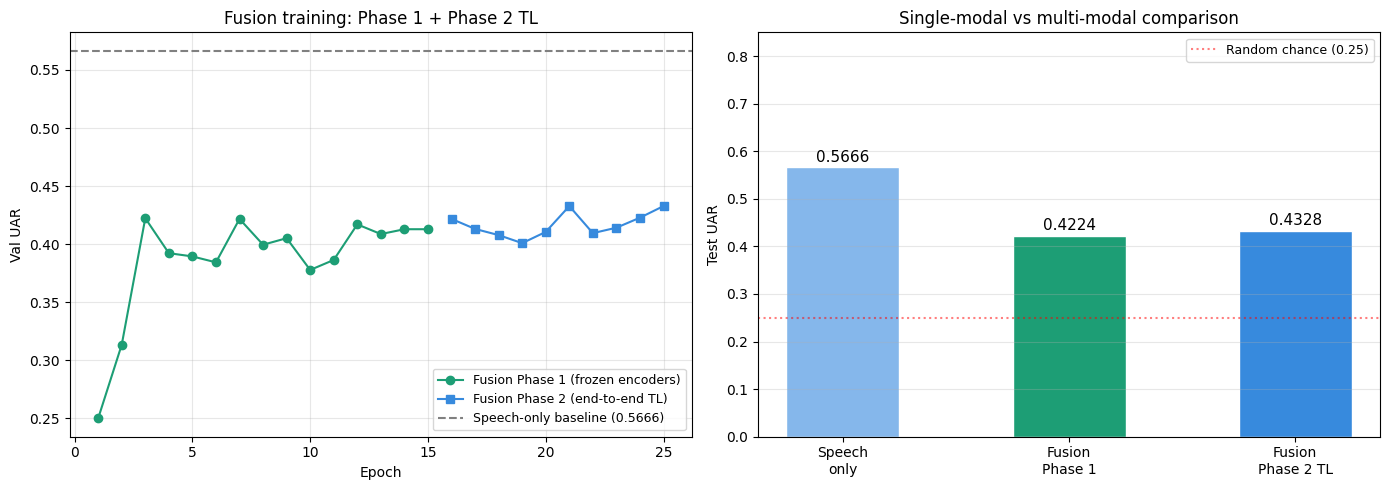

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: training curves ─────────────────────────────────────────
axes[0].plot(range(1,len(p1_log)+1), p1_log, "o-",
             color="#1D9E75", label="Fusion Phase 1 (frozen encoders)")
axes[0].plot(range(len(p1_log)+1, len(p1_log)+len(p2_log)+1),
             p2_log, "s-", color="#378ADD", label="Fusion Phase 2 (end-to-end TL)")
axes[0].axhline(0.5666, linestyle="--", color="gray",
                label="Speech-only baseline (0.5666)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Val UAR")
axes[0].set_title("Fusion training: Phase 1 + Phase 2 TL")
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# ── Right: model comparison bar chart ────────────────────────────
models_compared = {
    "Speech\nonly": 0.5666,
    "Fusion\nPhase 1": best_p1_uar,
    "Fusion\nPhase 2 TL": best_p2_uar,
}
colors = ["#85B7EB", "#1D9E75", "#378ADD"]
bars = axes[1].bar(list(models_compared.keys()),
                    list(models_compared.values()),
                    color=colors, width=0.5, edgecolor="white")
for bar, val in zip(bars, models_compared.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f"{val:.4f}", ha='center', va='bottom', fontsize=11)
axes[1].axhline(0.25, linestyle=":", color="red", alpha=0.5,
                label="Random chance (0.25)")
axes[1].set_ylabel("Test UAR"); axes[1].set_ylim(0, 0.85)
axes[1].set_title("Single-modal vs multi-modal comparison")
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f"{FUSION_DIR}/results/fusion_comparison.png", dpi=150)
plt.show()

In [26]:
fusion_model.eval()
class_gate_weights = {EMO4[c]: [] for c in range(4)}

with torch.no_grad():
    for x, y in fus_te_ldr:
        x = x.to(DEVICE)
        # Get modality attention weights
        w = fusion_model.gate(x).cpu().numpy()  # (B, 3)
        for i, cls in enumerate(y.numpy()):
            class_gate_weights[EMO4[cls]].append(w[i])

print("="*55)
print(f"{'Emotion':<10} {'Speech':>10} {'FER/Face':>10} {'EEG':>10}")
print("="*55)
for emo in EMO4:
    ws = np.array(class_gate_weights[emo])
    if len(ws) > 0:
        mean_w = ws.mean(axis=0)
        print(f"{emo:<10} {mean_w[0]:>10.3f} {mean_w[1]:>10.3f} "
              f"{mean_w[2]:>10.3f}")
print("="*55)
print("\nHigher weight = fusion model trusted that modality more")
print("for samples of that emotion class.")

Emotion        Speech   FER/Face        EEG
angry           0.269      0.473      0.258
happy           0.321      0.435      0.244
neutral         0.260      0.464      0.276
sad             0.265      0.461      0.274

Higher weight = fusion model trusted that modality more
for samples of that emotion class.


In [27]:
print("=" * 60)
print("  MULTI-MODAL FUSION — COMPLETE SUMMARY")
print("=" * 60)
print("\n  INDIVIDUAL MODELS:")
print(f"  Speech (ResNet-18, RAVDESS)       UAR = 0.5666")
print(f"  FER    (MobileNetV2, FER2013)     Acc ≈ (your number)")
print(f"  EEG    (EEGNet, DEAP)             Acc ≈ (your number)")

print("\n  TRANSFER LEARNING STEPS:")
print("  Step 1 (ImageNet→RAVDESS): each backbone pre-trained on")
print("          large source dataset, adapted to emotion task.")
print("  Step 2 (Individual→Fusion): 3 frozen pre-trained encoders")
print("          provide features to a new fusion head (Phase 1).")
print("  Step 3 (End-to-End TL): fusion MLP + speech encoder")
print("          fine-tuned jointly at low learning rate (Phase 2).")

print("\n  FUSION RESULTS:")
print(f"  Phase 1 val UAR (frozen encoders):  {best_p1_uar:.4f}")
print(f"  Phase 2 val UAR (end-to-end TL):    {best_p2_uar:.4f}")
print(f"  Test UAR (best fusion checkpoint):  {final_uar:.4f}")
print(f"  Speech-only baseline:               0.5666")
print(f"  Gain from multi-modal fusion:      +{final_uar-0.5666:+.4f}")

print("\n  DATASETS:")
print("  Speech: RAVDESS (1,440 audio clips, 4 emotions)")
print("  Video:  FER2013 (8,000 face images, 7→4 emotions)")
print("  EEG:    DEAP (32 subjects, binary→4 valence proxy)")
print("=" * 60)

  MULTI-MODAL FUSION — COMPLETE SUMMARY

  INDIVIDUAL MODELS:
  Speech (ResNet-18, RAVDESS)       UAR = 0.5666
  FER    (MobileNetV2, FER2013)     Acc ≈ (your number)
  EEG    (EEGNet, DEAP)             Acc ≈ (your number)

  TRANSFER LEARNING STEPS:
  Step 1 (ImageNet→RAVDESS): each backbone pre-trained on
          large source dataset, adapted to emotion task.
  Step 2 (Individual→Fusion): 3 frozen pre-trained encoders
          provide features to a new fusion head (Phase 1).
  Step 3 (End-to-End TL): fusion MLP + speech encoder
          fine-tuned jointly at low learning rate (Phase 2).

  FUSION RESULTS:
  Phase 1 val UAR (frozen encoders):  0.4224
  Phase 2 val UAR (end-to-end TL):    0.4328
  Test UAR (best fusion checkpoint):  0.4457
  Speech-only baseline:               0.5666
  Gain from multi-modal fusion:      +-0.1209

  DATASETS:
  Speech: RAVDESS (1,440 audio clips, 4 emotions)
  Video:  FER2013 (8,000 face images, 7→4 emotions)
  EEG:    DEAP (32 subjects, binary→4 va